# Proyecto 1 - Inteligencia Artificial
## Predicción de Tarifas de Transporte en NYC
Alina Carías, Ignacio Méndez, Ariela Mishaan y Diego Soto

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Limpieza

### Carga y descripción de datos

In [2]:
# Carga de datos
df = pd.read_csv("train_final.csv")
df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1


**Variable objetivo:** fare_amount. 

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   key                1000000 non-null  object 
 1   fare_amount        1000000 non-null  float64
 2   pickup_datetime    1000000 non-null  object 
 3   pickup_longitude   1000000 non-null  float64
 4   pickup_latitude    1000000 non-null  float64
 5   dropoff_longitude  999990 non-null   float64
 6   dropoff_latitude   999990 non-null   float64
 7   passenger_count    1000000 non-null  int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 61.0+ MB


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,1000000.000000,1000000.000000,1000000.000000,999990.000000,999990.000000,1000000.000000
mean,11.348079,-72.526640,39.929008,-72.527860,39.919954,1.684924
std,9.822090,12.057937,7.626154,11.324494,8.201418,1.323911
min,-44.900000,-3377.680935,-3116.285383,-3383.296608,-3114.338567,0.000000
25%,6.000000,-73.992060,40.734965,-73.991385,40.734046,1.000000
50%,8.500000,-73.981792,40.752695,-73.980135,40.753166,1.000000
75%,12.500000,-73.967094,40.767154,-73.963654,40.768129,2.000000
max,500.000000,2522.271325,2621.628430,45.581619,1651.553433,208.000000


### Valores Nulos

In [4]:
df.isnull().sum()

key                   0
fare_amount           0
pickup_datetime       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude    10
dropoff_latitude     10
passenger_count       0
dtype: int64

In [5]:
df = df.dropna()

### Limpieza de Etiquetas y otras columnas

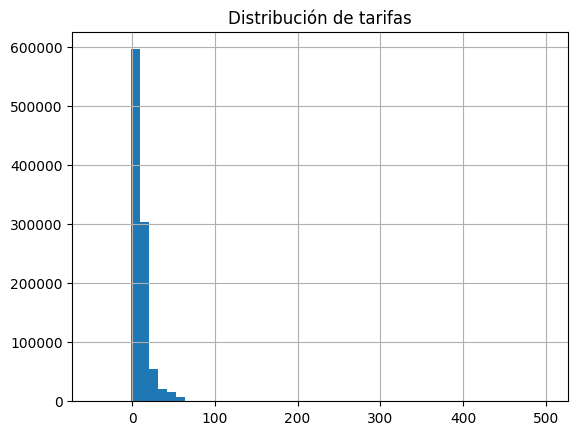

In [6]:
df["fare_amount"].hist(bins=50)
plt.title("Distribución de tarifas")
plt.show()

Se puede ver que las tarifas se encuentran entre 0 y $80, en general. Se eliminan entonces los datos que tienen tarifas mayores a $80. 

In [7]:
# dejar solo las etiquetas de la variable objetivo mayores a 0
df = df[df["fare_amount"] > 0]

# quitar valores muy altos para las tarifas
df = df[df["fare_amount"] < 80]

In [8]:
# limpieza de pasajeros
df["passenger_count"].value_counts()

# quitar los valores que no son reales: 0
df = df[(df["passenger_count"] > 0) & (df["passenger_count"] <= 6)]

### Limpieza Geográfica

Se conservan solo los datos que estén en NYC: 
- Latitud: 40 a 42
- Longitud: -75 a -72

**Fuente:** https://www.latlong.net/place/new-york-city-ny-usa-1848.html

In [9]:
df = df[
    (df["pickup_latitude"].between(40, 42)) &
    (df["dropoff_latitude"].between(40, 42)) &
    (df["pickup_longitude"].between(-75, -72)) &
    (df["dropoff_longitude"].between(-75, -72))
]

### Revisión de datos limpios

In [10]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,974755.000000,974755.000000,974755.000000,974755.000000,974755.000000,974755.000000
mean,11.248981,-73.975170,40.751063,-73.974215,40.751390,1.691176
std,9.182506,0.038832,0.029945,0.037519,0.032960,1.306309
min,0.010000,-74.968142,40.052722,-74.964263,40.041180,1.000000
25%,6.000000,-73.992272,40.736577,-73.991557,40.735618,1.000000
50%,8.500000,-73.982085,40.753407,-73.980583,40.753880,1.000000
75%,12.500000,-73.968324,40.767572,-73.965322,40.768415,2.000000
max,79.990000,-72.702870,41.800252,-72.694838,41.923820,6.000000


## Análisis Exploratorio

### Distribución de Tarifas

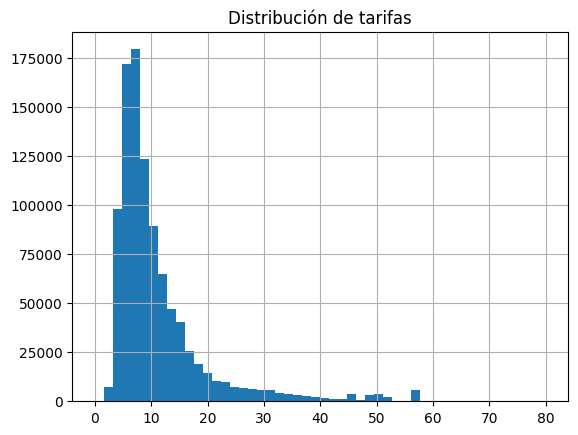

In [11]:
df["fare_amount"].hist(bins=50)
plt.title("Distribución de tarifas")
plt.show()

In [12]:
len((df[df["fare_amount"] > 60]))

1572

Se puede observar que la mayoría de los datos se concentran entre 0 y 20. Esto indica que las tarifas son bastante bajas. Hay 1572 outliers que se encuentran arriba de $60. 

### Distribución de Pasajeros

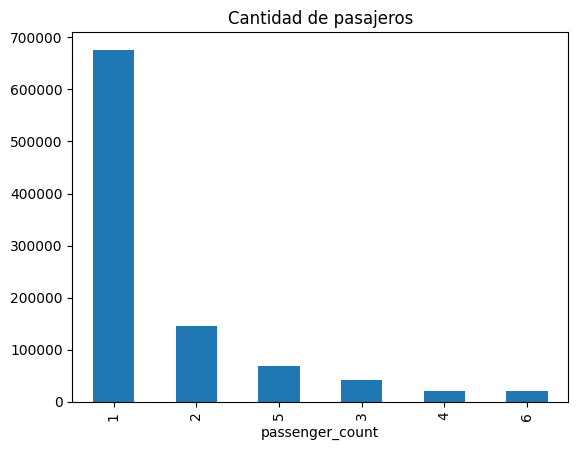

In [13]:
df["passenger_count"].value_counts().plot(kind="bar")
plt.title("Cantidad de pasajeros")
plt.show()

### Ubicaciones

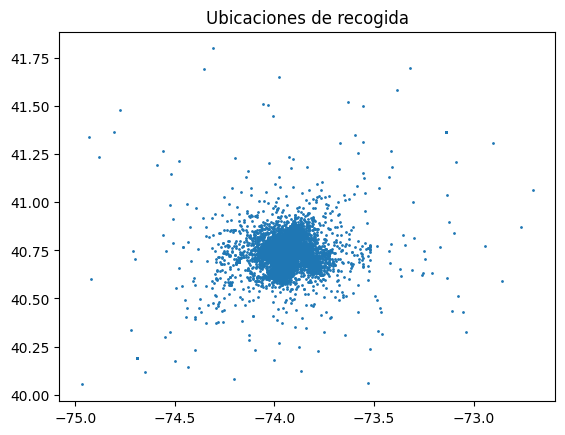

In [14]:
plt.scatter(df["pickup_longitude"], df["pickup_latitude"], s=1)
plt.title("Ubicaciones de recogida")
plt.show()

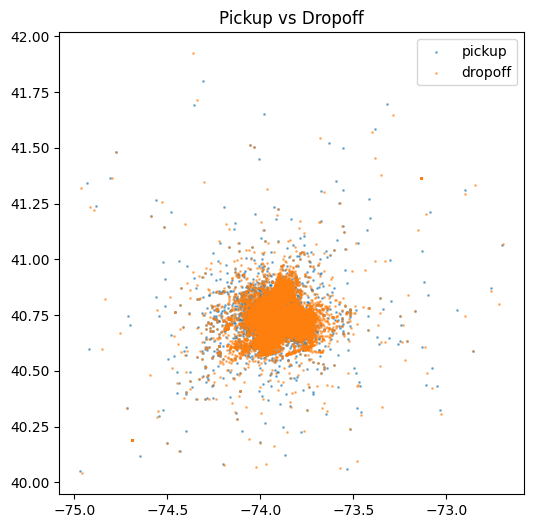

In [15]:
# distribución pickups vs dropoffs
plt.figure(figsize=(6,6))
plt.scatter(df["pickup_longitude"], df["pickup_latitude"], s=1, label="pickup", alpha=0.5)
plt.scatter(df["dropoff_longitude"], df["dropoff_latitude"], s=1, label="dropoff", alpha=0.5)
plt.legend()
plt.title("Pickup vs Dropoff")
plt.show()

### Relación tarifa vs pasajeros

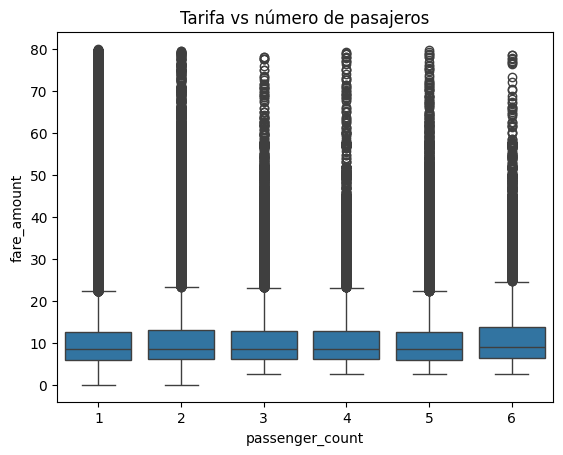

In [16]:
sns.boxplot(x="passenger_count", y="fare_amount", data=df)
plt.title("Tarifa vs número de pasajeros")
plt.show()

El gráfico de caja y bigotes muestra que la tarifa no cambia según los pasajeros. Esto indica que la variable ```passenger_count``` no es influyente para nuestra variable objetivo. 

## Feature Engineering (Análisis de Características)

### Distancia 

In [17]:
# fórmula de Haversine
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [18]:
df["distance_km"] = haversine(
    df["pickup_latitude"],
    df["pickup_longitude"],
    df["dropoff_latitude"],
    df["dropoff_longitude"]
)

In [19]:
# limpieza de distancias
df = df[df["distance_km"] > 0]
df = df[df["distance_km"] < 100]

### Variables temporales

In [20]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

In [21]:
# crear las variables
df["hour"] = df["pickup_datetime"].dt.hour
df["day_of_week"] = df["pickup_datetime"].dt.dayofweek
df["month"] = df["pickup_datetime"].dt.month
df["year"] = df["pickup_datetime"].dt.year

In [22]:
df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

In [23]:
df["is_rush_hour"] = df["hour"].isin([7,8,9,16,17,18,19]).astype(int)

### Zonas de interés

In [24]:
JFK = (-73.7781, 40.6413)
LGA = (-73.8740, 40.7769)
EWR = (-74.1745, 40.6895)

In [25]:
def is_near_airport(lat, lon, airport_lat, airport_lon, threshold=10):
    return haversine(lat, lon, airport_lat, airport_lon) < threshold

In [26]:
df["pickup_jfk"] = is_near_airport(df["pickup_latitude"], df["pickup_longitude"], *JFK)
df["dropoff_jfk"] = is_near_airport(df["dropoff_latitude"], df["dropoff_longitude"], *JFK)

df["pickup_lga"] = is_near_airport(df["pickup_latitude"], df["pickup_longitude"], *LGA)
df["dropoff_lga"] = is_near_airport(df["dropoff_latitude"], df["dropoff_longitude"], *LGA)

df["pickup_ewr"] = is_near_airport(df["pickup_latitude"], df["pickup_longitude"], *EWR)
df["dropoff_ewr"] = is_near_airport(df["dropoff_latitude"], df["dropoff_longitude"], *EWR)

In [27]:
cols = ["pickup_jfk","dropoff_jfk","pickup_lga","dropoff_lga","pickup_ewr","dropoff_ewr"]
df[cols] = df[cols].astype(int)

In [28]:
df["pickup_ewr"].describe()

count    964285.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: pickup_ewr, dtype: float64

### Análisis de las características

In [29]:
df.columns

Index(['key', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count', 'distance_km', 'hour', 'day_of_week', 'month',
       'year', 'is_weekend', 'is_rush_hour', 'pickup_jfk', 'dropoff_jfk',
       'pickup_lga', 'dropoff_lga', 'pickup_ewr', 'dropoff_ewr'],
      dtype='object')

#### Tarifa por hora

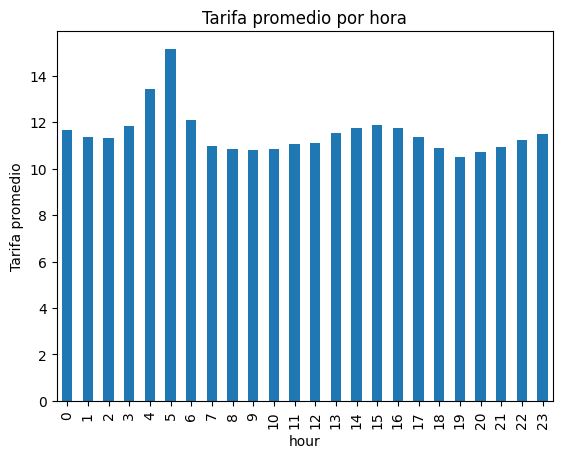

In [30]:
# tarifa promedio por hora
df.groupby("hour")["fare_amount"].mean().plot(kind="bar")
plt.title("Tarifa promedio por hora")
plt.ylabel("Tarifa promedio")
plt.show()

Se puede ver que durante las horas del día existen variaciones. Por ejemplo, de 3 a 6 de la mañana, las tarifas suben bastante. En las horas pico de la tarde, entre 2pm y 5pm, las tarifas también suben, pero el cambio no es tanto. 

#### Tarifa por día de la semana

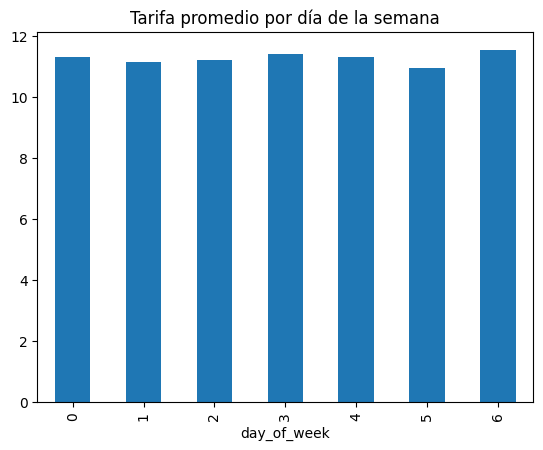

In [31]:
# día de la semana
df.groupby("day_of_week")["fare_amount"].mean().plot(kind="bar")
plt.title("Tarifa promedio por día de la semana")
plt.show()

El día de la semana no pareciera ser una variable significativa para la variable objtivo. Se puede ver que el valor de la tarifa no cambia tanto según el día de la semana (0 = lunes, 6 = domingo). 

#### Tarifa por mes

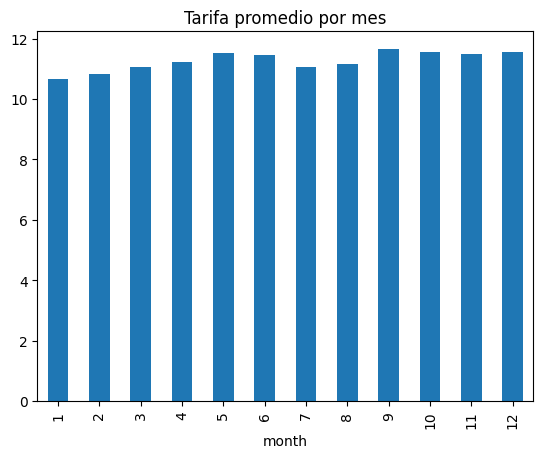

In [32]:
# mes 
df.groupby("month")["fare_amount"].mean().plot(kind="bar")
plt.title("Tarifa promedio por mes")
plt.show()

Las tarifas del taxi no parecieran tener estacionalidad. Aunque hay unos meses con tarifas un poco más altas y otras con unas un poco más bajas, el cambio en general es muy bajo.  

#### Tarifa por año

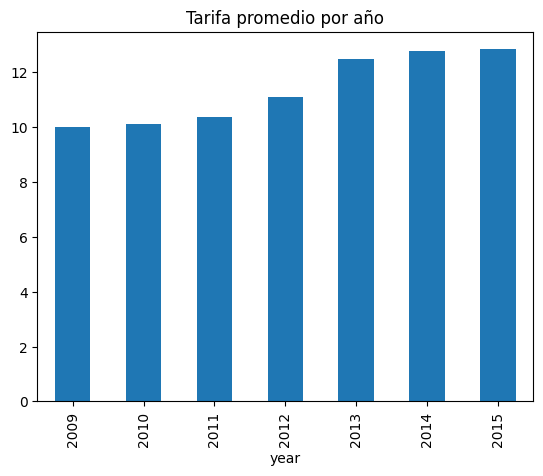

In [33]:
# año
df.groupby("year")["fare_amount"].mean().plot(kind="bar")
plt.title("Tarifa promedio por año")
plt.show()

El gráfico de barras muestra que las tarifas promedio han ido subiendo con los años. En 2009, el promedio se encontraba alrededor de $10, y fue subiendo gradualmente, hasta llegar al 2015 con una tarifa promedio de alrededor de $13. 

#### Fin de semana

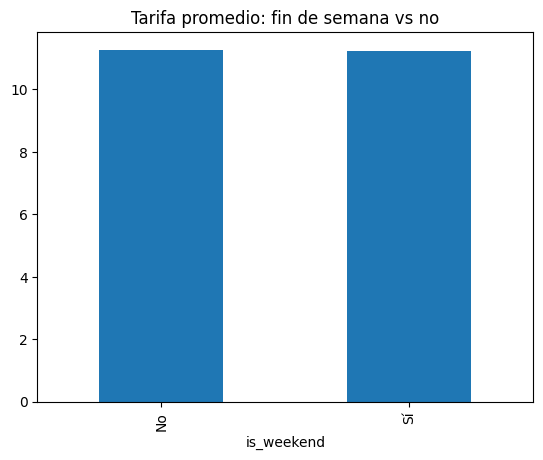

In [34]:
df.groupby("is_weekend")["fare_amount"].mean().plot(kind="bar")
plt.title("Tarifa promedio: fin de semana vs no")
plt.xticks([0,1], ["No", "Sí"])
plt.show()

El hecho de ser fin de semana no influye significativamente en la tarifa promedio de los taxis, eso quiere decir que la variable no es tan influyente. 

#### Hora pico

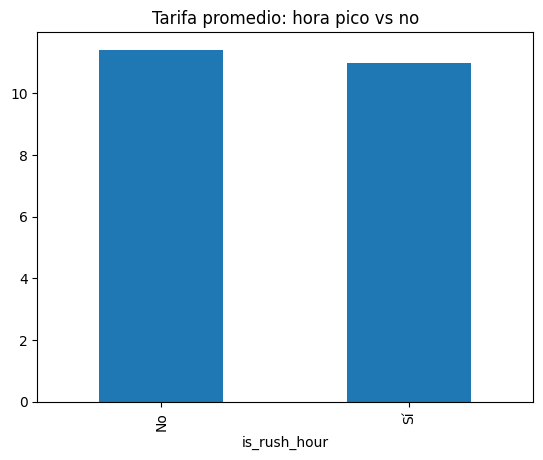

In [35]:
df.groupby("is_rush_hour")["fare_amount"].mean().plot(kind="bar")
plt.title("Tarifa promedio: hora pico vs no")
plt.xticks([0,1], ["No", "Sí"])
plt.show()

La hora pico tampoco parece ser un factor de influencia en la tarifa. Los datos que no son en hora pico mostraron tener una tarifa más alta. Esto indica que en realidad el dato de la hora pico no determina la tarifa. 

#### Distancia

/var/folders/p9/c7lshh9n1j55x6_b26v_sx1h0000gn/T/ipykernel_16943/558831060.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("distance_bin")["fare_amount"].mean().plot(kind="bar")


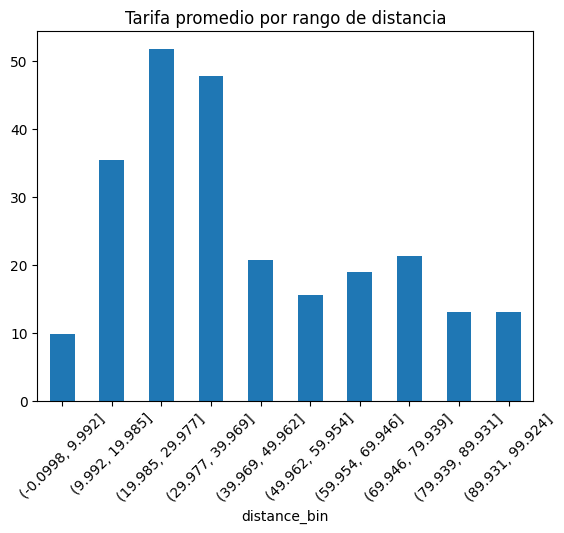

In [36]:
df["distance_bin"] = pd.cut(df["distance_km"], bins=10)

df.groupby("distance_bin")["fare_amount"].mean().plot(kind="bar")
plt.title("Tarifa promedio por rango de distancia")
plt.xticks(rotation=45)
plt.show()

#### Matriz de correlación

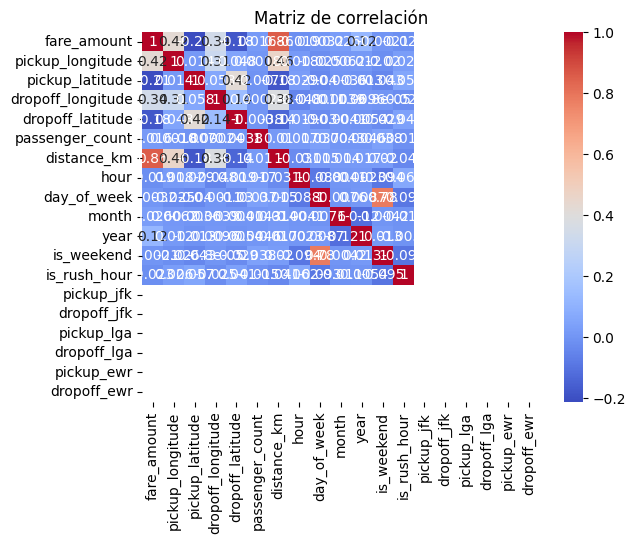

In [37]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

## Preparación de datos

In [38]:
# Selección de features
features = [
    "distance_km", "passenger_count",
    "hour", "day_of_week", "month",
    "is_weekend", "is_rush_hour",
    "pickup_jfk","dropoff_jfk",
    "pickup_lga","dropoff_lga",
    "pickup_ewr","dropoff_ewr"
]

X = df[features]
y = df["fare_amount"]

## Train/test split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Modelos

### Regresión lineal

In [40]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### Random forest

In [41]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

### KNN

In [42]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=7, weights='distance')
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

## Evaluación

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluar(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse
    }

print("LR:", evaluar(y_test, y_pred_lr))
print("RF:", evaluar(y_test, y_pred_rf))
print("KNN:", evaluar(y_test, y_pred_knn))

LR: {'MAE': 2.3852273337507097, 'RMSE': 4.680752723877499}
RF: {'MAE': 2.1997967877581552, 'RMSE': 3.998589486092729}
KNN: {'MAE': 2.5091964216220615, 'RMSE': 4.527169708137233}


Se evaluaron tres modelos utilizando las métricas MAE y RMSE.
- El MAE muestra el error promedio en dólares de las predicciones
- El RMSE penaliza más los errores grandes, por lo que es útil para detectarpredicciones muy alejadas a la realidad. 

Resultados obtenidos:

- Regresión Lineal: MAE = 2.38, RMSE = 4.68
- Random Forest: MAE = 2.20, RMSE = 4.00
- KNN: MAE = 2.51, RMSE = 4.53

## Comparación

In [44]:
results = pd.DataFrame({
    "Modelo": ["Linear Regression", "Random Forest", "KNN"],
    "MAE": [
        evaluar(y_test, y_pred_lr)["MAE"],
        evaluar(y_test, y_pred_rf)["MAE"],
        evaluar(y_test, y_pred_knn)["MAE"]
    ],
    "RMSE": [
        evaluar(y_test, y_pred_lr)["RMSE"],
        evaluar(y_test, y_pred_rf)["RMSE"],
        evaluar(y_test, y_pred_knn)["RMSE"]
    ]
})

results

,Modelo,MAE,RMSE
0,Linear Regression,2.385227,4.680753
1,Random Forest,2.199797,3.998589
2,KNN,2.509196,4.527170


El modelo Random Forest presenta el mejor desempeño, ya que tiene el menor MAE y RMSE entre los tres modelos evaluados.

Esto indica que:
- Sus predicciones son, en promedio, más cercanas a los valores reales.
- Maneja mejor los errores grandes en comparación con los otros modelos.

Los resultados muestran que el Random Forest es el más fuerte, porque logra el menor MAE (2.20) y también el menor RMSE (4.00), lo que significa que sus predicciones son más precisas y menos propensas a errores grandes. 
La regresión lineal tiene un desempeño aceptable, con un MAE relativamente bajo (2.38), aunque el RMSE (4.68) indica que puede fallar más en casos extremos. 
Por otro lado, el modelo de KNN resulta menos favorable, ya que presenta el mayor MAE (2.51) y un RMSE elevado (4.53), lo que refleja tanto errores promedio más altos como cierta vulnerabilidad ante predicciones alejadas de la realidad. 

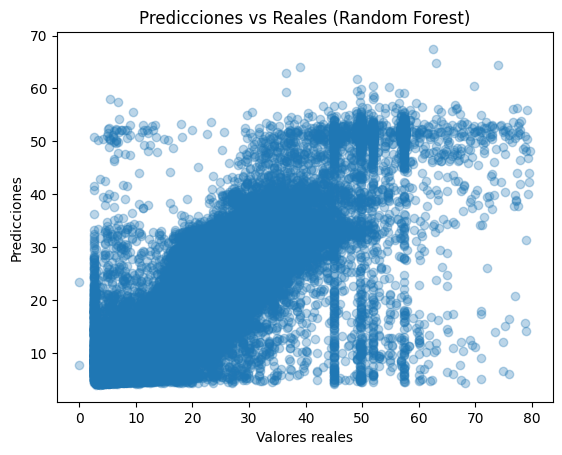

In [45]:
plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Predicciones vs Reales (Random Forest)")
plt.show()

El modelo seleccionado es **Random Forest** por su mejor desempeño en las métricas evaluadas. 

Además, es capaz de capturar relaciones no lineales entre variables, lo cual es importante en problemas reales como la predicción de tarifas. Es robusto con outliers y riudo en los datos. Y, no requiere supuestos fuertes como la regresión lineal. 

Aunque su costo computacional es mayor, el aumento en precisión justifica su uso en este caso. 

### Importancio de las variables

In [46]:
importancias = pd.Series(rf.feature_importances_, index=X.columns)
importancias.sort_values(ascending=False)

distance_km        0.967252
hour               0.014744
month              0.007542
day_of_week        0.005322
passenger_count    0.003392
is_weekend         0.001023
is_rush_hour       0.000725
pickup_jfk         0.000000
dropoff_jfk        0.000000
pickup_lga         0.000000
dropoff_lga        0.000000
pickup_ewr         0.000000
dropoff_ewr        0.000000
dtype: float64

La variable más importante es la distancia del viaje, lo cual es lógico ya que el costo del taxi depende directamente de la longitud del recorrido. 

Otras variables relevantes son la hora del día y las variables relacionadas con aeropuestos. Esto confirma que las características creadas durante el feature engineering son útiles para el modelo. 

## Función de predicción

In [47]:
def predict_fare(pickup_lat, pickup_lon, dropoff_lat, dropoff_lon, passengers, datetime):
    dt = pd.to_datetime(datetime)

    distance = haversine(
        pickup_lat, pickup_lon,
        dropoff_lat, dropoff_lon
    )

    data = pd.DataFrame([{
        "distance_km": distance,
        "passenger_count": passengers,
        "hour": dt.hour,
        "day_of_week": dt.weekday(),
        "month": dt.month,
        "is_weekend": int(dt.weekday() in [5,6]),
        "is_rush_hour": int(dt.hour in [7,8,9,16,17,18,19]),
        "pickup_jfk": is_near_airport(pickup_lat, pickup_lon, -73.7781, 40.6413),
        "dropoff_jfk": is_near_airport(dropoff_lat, dropoff_lon, -73.7781, 40.6413),
        "pickup_lga": is_near_airport(pickup_lat, pickup_lon, -73.8740, 40.7769),
        "dropoff_lga": is_near_airport(dropoff_lat, dropoff_lon, -73.8740, 40.7769),
        "pickup_ewr": is_near_airport(pickup_lat, pickup_lon, -74.1745, 40.6895),
        "dropoff_ewr": is_near_airport(dropoff_lat, dropoff_lon, -74.1745, 40.6895),
    }])

    return rf.predict(data)[0]

Esta función permite predecir el costo de un viaje con un conjunto de variables de entrada. Se utilizan las mismas transformaciones aplicadas durante el entrenamiento (distancia, variables temporales y aeropuertos), asegurando consistencia en las predicciones. 

In [48]:
predict_fare(40.75, -73.99, 40.78, -73.95, 2, "2015-06-15 08:30:00")

14.532573237509578

### Pruebas de usuario

In [49]:
tests = [
    (40.75, -73.99, 40.78, -73.95, 2, "2015-06-15 08:30:00"),
    (40.70, -74.00, 40.75, -73.98, 1, "2014-03-10 14:00:00"),
    (40.76, -73.98, 40.80, -73.95, 3, "2013-11-20 19:00:00"),
    (40.72, -73.99, 40.74, -73.97, 1, "2012-01-05 09:00:00"),
    (40.77, -73.87, 40.75, -73.99, 2, "2015-07-01 12:00:00"),
    (40.64, -73.78, 40.75, -73.99, 1, "2015-08-15 16:00:00"),
    (40.75, -73.99, 40.76, -73.98, 1, "2015-09-10 10:00:00"),
    (40.73, -73.98, 40.78, -73.95, 4, "2014-05-20 18:30:00"),
    (40.70, -73.95, 40.72, -73.90, 2, "2013-06-25 22:00:00"),
    (40.78, -73.96, 40.80, -73.94, 1, "2015-12-01 07:30:00")
]

results = []

for t in tests:
    pred = predict_fare(*t)
    results.append(pred)

pd.DataFrame({
    "Test": range(1,11),
    "Predicted Fare": results
})

,Test,Predicted Fare
0,1,14.532573
1,2,16.205483
2,3,15.424615
3,4,10.522346
4,5,33.260376
5,6,50.709142
6,7,7.570738
7,8,18.042137
8,9,13.349183
9,10,8.460353


In [50]:
df_tests = pd.DataFrame(tests, columns=[
    "pickup_lat", "pickup_lon", "dropoff_lat", "dropoff_lon",
    "passengers", "datetime"
])

df_tests["datetime"] = pd.to_datetime(df_tests["datetime"])

df_tests["distance_km"] = haversine(
    df_tests["pickup_lat"],
    df_tests["pickup_lon"],
    df_tests["dropoff_lat"],
    df_tests["dropoff_lon"]
)

df_tests["hour"] = df_tests["datetime"].dt.hour
df_tests["day"] = df_tests["datetime"].dt.day_name()
df_tests["is_weekend"] = df_tests["datetime"].dt.weekday >= 5
df_tests["is_rush_hour"] = df_tests["hour"].isin([7,8,9,16,17,18,19])

df_tests["predicted_fare"] = results

df_tests

,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,passengers,datetime,distance_km,hour,day,is_weekend,is_rush_hour,predicted_fare
0,40.75,-73.99,40.78,-73.95,2,2015-06-15 08:30:00,4.740913,8,Monday,False,True,14.532573
1,40.70,-74.00,40.75,-73.98,1,2014-03-10 14:00:00,5.809586,14,Monday,False,False,16.205483
2,40.76,-73.98,40.80,-73.95,3,2013-11-20 19:00:00,5.115025,19,Wednesday,False,True,15.424615
3,40.72,-73.99,40.74,-73.97,1,2012-01-05 09:00:00,2.790306,9,Thursday,False,True,10.522346
4,40.77,-73.87,40.75,-73.99,2,2015-07-01 12:00:00,10.348742,12,Wednesday,False,False,33.260376
5,40.64,-73.78,40.75,-73.99,1,2015-08-15 16:00:00,21.518739,16,Saturday,True,True,50.709142
6,40.75,-73.99,40.76,-73.98,1,2015-09-10 10:00:00,1.394962,10,Thursday,False,False,7.570738
7,40.73,-73.98,40.78,-73.95,4,2014-05-20 18:30:00,6.107058,18,Tuesday,False,True,18.042137
8,40.70,-73.95,40.72,-73.90,2,2013-06-25 22:00:00,4.765176,22,Tuesday,False,False,13.349183
9,40.78,-73.96,40.80,-73.94,1,2015-12-01 07:30:00,2.789388,7,Tuesday,False,True,8.460353


## Evaluación del modelo

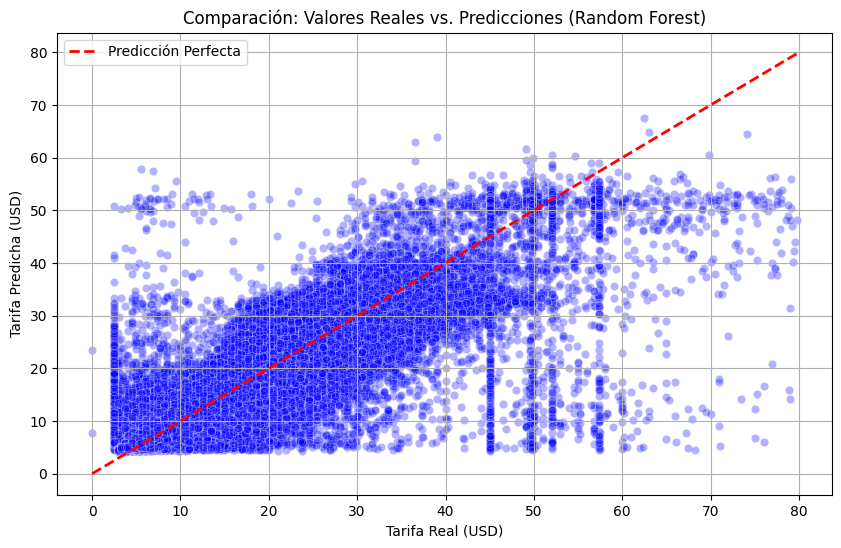

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.3, color='blue')
max_val = max(max(y_test), max(y_pred_rf))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', lw=2, label='Predicción Perfecta')

plt.title('Comparación: Valores Reales vs. Predicciones (Random Forest)')
plt.xlabel('Tarifa Real (USD)')
plt.ylabel('Tarifa Predicha (USD)')
plt.legend()
plt.grid(True)
plt.show()

Este gráfico de dispersión permite visualizar de manera directa qué tan bien el modelo logra aproximarse a los valores reales. Como la mayoría de los puntos se alinean con la diagonal roja, esto indica un buen desempeño predictivo. En particular, para tarifas bajas y medias (entre $0 y $40), la precisión es muy alta, ya que los puntos se concentran fuertemente alrededor de la línea. Aunque las tarifas más altas se observa mayor dispersión, esto es esperable porque los viajes caros dependen de factores externos. Aun así, el modelo mantiene la tendencia general, lo que confirma su utilidad. 

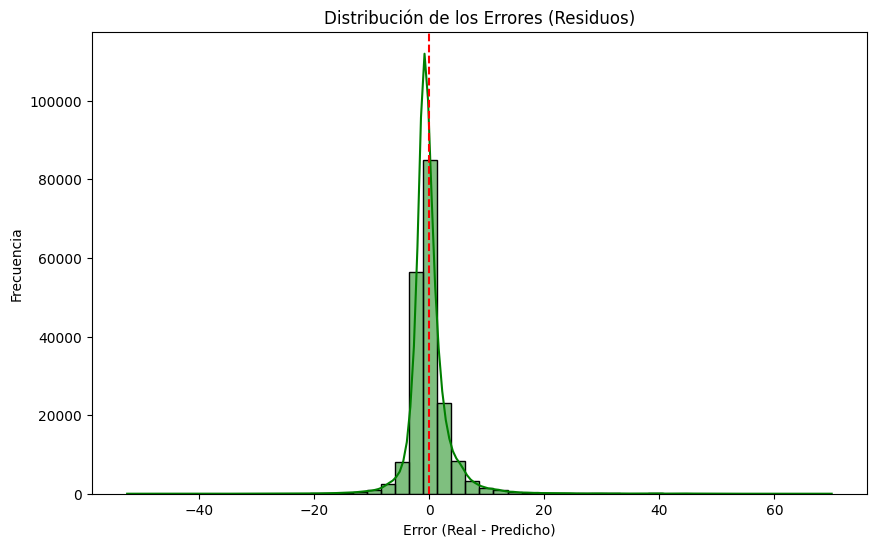

In [51]:
errores = y_test - y_pred_rf
plt.figure(figsize=(10, 6))
sns.histplot(errores, bins=50, kde=True, color='green')
plt.title('Distribución de los Errores (Residuos)')
plt.xlabel('Error (Real - Predicho)')
plt.ylabel('Frecuencia')
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

El histograma de errores es importante para evaluar la imparcialidad del modelo. La forma de camapana centrada en el cero muestra que la mayoría de las predicciones tienen diferencias mínimas respecto a los valores reales. La simetría de la distribución confirma que no existe un sesgo sistemático: el modelo no tiende a sobreestimar ni subestimar de manera consistente. Además, los brazos cortos de la campana reflejan que los errores grandes son poco frecuentes, lo que refuerza la confiabilidad del modelo y su capacidad de ofrecer estimaciones balanceadas y justas. 

## Conclusión general


En este proyecto se desarrolló un modelo predictivo para estimar tarifas de taxi en NYC.

Se realizaron las siguientes etapas:
- Limpieza de datos
- Ingeniería de características
- Entrenamiento de múltiples modelos

El modelo Random Forest obtuvo el mejor desempeño, demostrando que los modelos basados en árboles son más adecuados para este tipo de problema.
Finalmente, se construyó una función capaz de predecir nuevas tarifas, lo cual cumple con el objetivo del proyecto.